# 01. Multi-Agent 패턴 개요

> 단일 에이전트로 풀기 힘든 작업은 여러 에이전트를 협력시켜 풀어요. Subagents · Handoffs · Router · Skills · Custom Workflow 5가지 패턴의 차이를 한눈에 비교해요.

## 학습 목표

이 노트북을 마치면 다음을 할 수 있어요:

1. 멀티에이전트(Multi-Agent) 시스템이 필요한 이유를 설명할 수 있어요
2. 5가지 핵심 멀티에이전트 패턴(Subagents, Handoffs, Router, Skills, Custom Workflow)을 비교하고 구분할 수 있어요
3. 각 패턴의 모델 호출 수, 토큰 비용, 적합한 시나리오를 파악할 수 있어요
4. 실제 문제 상황에 맞는 패턴을 선택하고 간단한 구현 예제를 작성할 수 있어요

## 사전 지식

- Part 07 `02-Long-Term-Memory.ipynb`에서 배운 Store API와 세션 간 공유
- LangGraph StateGraph, 노드(Node), 엣지(Edge) 기초
- `create_agent` 함수와 LangChain V1 에이전트 기초
- Tool 정의와 바인딩 방법

## 왜 멀티에이전트인가?

단일 에이전트로 모든 것을 처리하면 어떤 문제가 생길까요?

| 문제 | 설명 | 영향 |
|------|------|------|
| **도구 과부하** | 한 에이전트에 도구가 너무 많아지면 잘못된 도구를 선택함 | 정확도 저하 |
| **컨텍스트 오버플로우** | 대화가 길어질수록 중요한 정보를 잊어버림 | 일관성 깨짐 |
| **전문화 부재** | 하나의 에이전트가 모든 분야를 다루면 깊이가 없음 | 품질 저하 |
| **확장성 한계** | 기능을 추가할 때마다 프롬프트가 복잡해짐 | 유지보수 어려움 |

멀티에이전트 시스템은 이 문제들을 **분업(Specialization)**과 **조율(Orchestration)**로 해결해요.

> 🎯 **강의 포인트**: 멀티에이전트 시스템은 **회사 조직**과 같아요. 모든 일을 혼자 하는 1인 기업 vs 전문가 팀 시스템의 차이를 생각해보세요. 1인 기업(단일 에이전트)은 단순한 일에 빠르지만, 복잡한 프로젝트에서는 팀(멀티에이전트)이 훨씬 효과적이에요.

> 🔑 **핵심 개념**: 멀티에이전트 시스템의 핵심은 **각 에이전트가 자신의 전문 영역에만 집중**하고, **오케스트레이터(Orchestrator)**가 전체 흐름을 관리한다는 것이에요.

### 5가지 패턴을 한 줄로 요약하면?

| 패턴 | 한 줄 비유 |
|------|-----------|
| **Subagents** | 팀장이 팀원에게 업무를 지시하고 보고받는 구조 |
| **Handoffs** | 공항 체크인 → 보안검색 → 탑승구처럼 고객을 다음 창구로 안내 |
| **Router** | 우체국에서 편지를 지역별로 분류해 동시에 배달하는 구조 |
| **Skills** | 스마트폰에 앱을 필요할 때만 설치하는 것처럼 능력을 동적 로딩 |
| **Custom Workflow** | 위 4가지를 레고 블록처럼 조합하는 맞춤형 설계 |

## 5가지 멀티에이전트 패턴 전체 아키텍처

LangChain V1은 5가지 멀티에이전트 패턴을 제공해요. 각 패턴은 서로 다른 문제를 해결하기 위해 설계되었어요.

```mermaid
flowchart TB
    U(["사용자 요청<br>User Request"])

    subgraph patterns["5가지 멀티에이전트 패턴"]
        P1["1. Subagents<br>도구로 위임"]
        P2["2. Handoffs<br>에이전트 간 인계"]
        P3["3. Router<br>병렬 분기"]
        P4["4. Skills<br>온디맨드 능력 로딩"]
        P5["5. Custom Workflow<br>패턴 조합"]
    end

    A1["전문 에이전트 A"]
    A2["전문 에이전트 B"]
    R(["최종 응답"])

    U --> patterns
    P1 --> A1
    P2 --> A1
    P3 --> A1
    P3 --> A2
    P4 --> A1
    P5 --> A1
    P5 --> A2
    A1 --> R
    A2 --> R

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404
    classDef storage fill:#e2d5f1,stroke:#6f42c1,color:#3d1f6e

    class U input
    class P1,P2,P3,P4,P5 process
    class A1,A2 storage
    class R output
```

각 패턴의 핵심 차이를 먼저 표로 정리해볼게요:

| 패턴 | 제어 흐름 | 모델 호출 수 | 주요 사용 사례 |
|------|----------|------------|---------------|
| **Subagents** | 중앙 집중식 (도구 호출) | 높음 (N+1) | 작업 오케스트레이션 |
| **Handoffs** | 분산형 (에이전트 인계) | 중간 (N) | 다중 도메인 대화 |
| **Router** | 병렬 분기 | 낮음 (1+parallel) | 입력 분류 후 병렬 처리 |
| **Skills** | 단일 에이전트 확장 | 낮음 (1) | 온디맨드 능력 확장 |
| **Custom Workflow** | 혼합 | 가변 | 복잡한 맞춤형 파이프라인 |

## 환경 설정

In [1]:
# ---------------------------------------------------
# 환경 변수 로드
# ---------------------------------------------------
# .env 파일에서 API 키를 불러와요
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
# ---------------------------------------------------
# LangSmith 추적 설정 (선택사항)
# ---------------------------------------------------
# 실행 과정을 LangSmith에서 시각적으로 추적해요
import os

# os.environ["LANGCHAIN_TRACING_V2"] = "true"
# os.environ["LANGCHAIN_PROJECT"] = "LangGraph-MultiAgent-Overview"

# LangSmith 추적 설정 완료

## 1. Subagents 패턴 - 도구로서의 에이전트

### 개념

**Subagents 패턴**은 중앙 슈퍼바이저 에이전트가 다른 에이전트를 **도구(tool)**로 호출하는 방식이에요.

마치 팀장이 팀원에게 업무를 지시하고, 결과를 보고받는 구조와 같아요.

```mermaid
flowchart LR
    S(["슈퍼바이저<br>Supervisor"])
    T1["Research Agent<br>@tool"]
    T2["Math Agent<br>@tool"]
    T3["Writer Agent<br>@tool"]

    S -- "도구 호출" --> T1
    S -- "도구 호출" --> T2
    S -- "도구 호출" --> T3
    T1 -- "결과 반환" --> S
    T2 -- "결과 반환" --> S
    T3 -- "결과 반환" --> S

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085

    class S input
    class T1,T2,T3 process
```

**특징:**
- 슈퍼바이저가 **모든 컨텍스트를 유지**해요
- 하위 에이전트는 독립적으로 실행되고 **결과만 반환**해요
- 슈퍼바이저가 어떤 에이전트를 호출할지 **LLM이 결정**해요

> 🔑 **핵심 개념**: Subagents 패턴에서 하위 에이전트는 사용자와 직접 대화하지 않아요. 슈퍼바이저가 중간에서 모든 커뮤니케이션을 처리해요.

> ⚠️ **자주 하는 실수**: 하위 에이전트에 너무 많은 도구를 줘서 각 에이전트가 과부하되는 경우가 있어요. 각 에이전트는 **단일 책임 원칙**을 따라야 해요.

In [3]:
# ---------------------------------------------------
# Subagents 패턴 기본 구조
# ---------------------------------------------------
# LangChain V1의 create_agent와 @tool 데코레이터를 사용해요
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent
from langchain.tools import tool

# 기본 모델: gpt-4o-mini (비용 효율적)
# Anthropic: "anthropic:claude-sonnet-4-5"
# Ollama 로컬: "ollama:llama3"
model = init_chat_model("openai:gpt-4o-mini")

print("모델 초기화 완료:", type(model).__name__)

모델 초기화 완료: ChatOpenAI


In [4]:
# ---------------------------------------------------
# 하위 에이전트 정의: 수학 계산 전문
# ---------------------------------------------------
# 간단한 덧셈/곱셈 도구를 가진 수학 에이전트를 만들어요
def add(a: float, b: float) -> float:
    """두 숫자를 더해요."""
    return a + b


def multiply(a: float, b: float) -> float:
    """두 숫자를 곱해요."""
    return a * b


# 수학 전문 하위 에이전트
math_subagent = create_agent(
    model=model,
    tools=[add, multiply],
    system_prompt=(
        "당신은 수학 계산 전문가예요. "
        "주어진 도구를 사용해 수식을 계산하고 한국어로 답변해요."
    ),
    name="math_subagent",
)

# 수학 하위 에이전트 생성 완료

In [5]:
# ---------------------------------------------------
# 하위 에이전트를 @tool로 래핑
# ---------------------------------------------------
# 슈퍼바이저가 도구로 호출할 수 있도록 @tool로 감싸요
@tool(
    "calculator_agent",
    description="수학 계산이 필요할 때 이 도구를 사용해요. 덧셈, 곱셈 등 산술 연산을 처리해요.",
)
def call_math_subagent(query: str) -> str:
    """수학 하위 에이전트를 호출하고 결과를 반환해요."""
    # 하위 에이전트 실행: 사용자 메시지로 질문 전달
    result = math_subagent.invoke(
        {"messages": [{"role": "user", "content": query}]}
    )
    # 마지막 메시지의 content를 반환해요
    return result["messages"][-1].content


# 슈퍼바이저 에이전트 (하위 에이전트를 도구로 활용)
supervisor = create_agent(
    model=model,
    tools=[call_math_subagent],  # 수학 에이전트를 도구로 제공
    system_prompt=(
        "당신은 유능한 어시스턴트예요. "
        "수학 계산이 필요하면 calculator_agent 도구를 사용하세요. "
        "한국어로 답변해요."
    ),
)

# Subagents 패턴 구성 완료
# 슈퍼바이저 -> calculator_agent (도구) -> math_subagent (에이전트)

In [6]:
# ---------------------------------------------------
# Subagents 패턴 실행 테스트
# ---------------------------------------------------
# 슈퍼바이저가 자동으로 수학 하위 에이전트를 호출하는지 확인해요
response = supervisor.invoke(
    {"messages": [{"role": "user", "content": "3 더하기 5를 계산하고 그 결과에 7을 곱해줘"}]}
)

# 최종 응답 출력
# === Subagents 패턴 결과 ===
print(response["messages"][-1].content)

3 더하기 5는 8이고, 그 결과에 7을 곱하면 56입니다.


## 2. Handoffs 패턴 - 에이전트 간 제어권 인계

### 개념

**Handoffs 패턴**은 현재 에이전트가 다른 에이전트로 **제어권(control)**을 넘기는 방식이에요. `Command(update={...})` 객체와 `ToolMessage` 페어링을 사용해요.

> 🎯 **강의 포인트**: Handoffs는 **병원 진료 시스템**과 같아요. 접수 창구(Supervisor)에서 증상을 듣고, 내과(Agent A)로 안내하고, 필요하면 영상의학과(Agent B)로 의뢰서와 함께 보내요. 각 단계에서 환자의 차트(State)가 함께 전달돼요.

```mermaid
flowchart LR
    U(["사용자"])
    A1["에이전트 A<br/>(현재 활성)"]
    A2["에이전트 B<br/>(인계 대상)"]
    A3["에이전트 C<br/>(인계 대상)"]

    U -- "메시지" --> A1
    A1 -- "Command(goto=B)" --> A2
    A2 -- "Command(goto=C)" --> A3
    A3 -- "최종 응답" --> U

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404

    class U input
    class A1,A2,A3 process
```

**Subagents vs Handoffs 차이:**

| 특성 | Subagents | Handoffs |
|------|----------|----------|
| 제어 흐름 | 중앙 집중 (팀장이 관리) | 분산 (에이전트끼리 직접 전달) |
| 컨텍스트 | 슈퍼바이저가 유지 | 에이전트가 직접 전달 |
| 사용자 상호작용 | 슈퍼바이저만 | 각 에이전트가 직접 가능 |
| 적합한 상황 | 작업 오케스트레이션 | 다중 도메인 대화 |

> 💡 **실무 팁**: 공식 문서에서는 단일 에이전트 + 미들웨어 조합을 Handoffs 패턴의 권장 구현으로 소개해요. 단순한 케이스에서는 에이전트를 여러 개 만드는 것보다 미들웨어로 제어하는 것이 더 효율적이에요.

In [7]:
# ---------------------------------------------------
# Handoffs 패턴 핵심: Command와 ToolMessage 페어링
# ---------------------------------------------------
# Command(update={...})를 이용해 에이전트 간 제어권을 넘겨요
from typing import Annotated
from langchain_core.tools import InjectedToolCallId
from langgraph.prebuilt import InjectedState
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.types import Command


def create_handoff_tool(agent_name: str, description: str = ""):
    """다른 에이전트로 제어권을 넘기는 핸드오프 도구를 만들어요."""
    # 도구 이름 동적 생성
    tool_name = f"handoff_to_{agent_name}"
    desc = description or f"{agent_name}에게 작업을 넘겨요."

    @tool(tool_name, description=desc)  # type: ignore
    def handoff_fn(
        state: Annotated[MessagesState, InjectedState],  # 현재 상태 자동 주입
        tool_call_id: Annotated[str, InjectedToolCallId],  # 도구 호출 ID 자동 주입
    ) -> Command:
        """핸드오프를 실행해요."""
        # ToolMessage: 핸드오프 성공 메시지 (Command와 반드시 페어링)
        tool_message = {
            "role": "tool",
            "content": f"{agent_name}에게 제어권이 넘어갔어요",
            "name": tool_name,
            "tool_call_id": tool_call_id,
        }
        # Command: 다음 에이전트(goto)로 라우팅 + 상태 업데이트
        return Command(
            goto=agent_name,  # 인계받을 에이전트 이름
            update={**state, "messages": state["messages"] + [tool_message]},
            graph=Command.PARENT,  # 부모 그래프에서 네비게이션
        )

    return handoff_fn


# 각 에이전트로의 핸드오프 도구 생성
to_billing = create_handoff_tool("billing_agent", "청구/결제 관련 문의를 청구 에이전트에게 넘겨요")
to_tech = create_handoff_tool("tech_agent", "기술 문제를 기술 에이전트에게 넘겨요")
to_supervisor = create_handoff_tool("supervisor_agent", "처리 완료 후 슈퍼바이저로 복귀해요")

# 핸드오프 도구 생성 완료
print(f"  - {to_billing.name}")
print(f"  - {to_tech.name}")
print(f"  - {to_supervisor.name}")

  - handoff_to_billing_agent
  - handoff_to_tech_agent
  - handoff_to_supervisor_agent


In [8]:
# ---------------------------------------------------
# Handoffs 패턴: 에이전트와 그래프 구성
# ---------------------------------------------------
# 슈퍼바이저, 청구 에이전트, 기술 에이전트를 하나의 그래프로 연결해요

# 슈퍼바이저: 문의 유형에 따라 적절한 에이전트로 핸드오프
supervisor_agent = create_agent(
    model=model,
    tools=[to_billing, to_tech],  # 핸드오프 도구 보유
    system_prompt=(
        "당신은 고객 지원 슈퍼바이저예요. "
        "청구/결제 문의는 billing_agent로, "
        "기술 문제는 tech_agent로 넘겨주세요."
    ),
    name="supervisor_agent",
)

# 청구 에이전트: 결제/환불 처리 후 슈퍼바이저로 복귀
billing_agent = create_agent(
    model=model,
    tools=[to_supervisor],
    system_prompt=(
        "당신은 청구/결제 전문가예요. "
        "청구 문제를 해결하고 supervisor_agent로 복귀해주세요."
    ),
    name="billing_agent",
)

# 기술 에이전트: 기술 지원 후 슈퍼바이저로 복귀
tech_agent = create_agent(
    model=model,
    tools=[to_supervisor],
    system_prompt=(
        "당신은 기술 지원 전문가예요. "
        "기술 문제를 해결하고 supervisor_agent로 복귀해주세요."
    ),
    name="tech_agent",
)

# -------------------------------------------
# StateGraph로 에이전트 간 흐름 연결
# -------------------------------------------
handoffs_graph = (
    StateGraph(MessagesState)
    .add_node(supervisor_agent, destinations=("billing_agent", "tech_agent", END))
    .add_node(billing_agent, destinations=("supervisor_agent",))
    .add_node(tech_agent, destinations=("supervisor_agent",))
    .add_edge(START, "supervisor_agent")      # 시작 -> 슈퍼바이저
    .add_edge("billing_agent", "supervisor_agent")  # 처리 후 복귀
    .add_edge("tech_agent", "supervisor_agent")     # 처리 후 복귀
    .compile()
)

# Handoffs 패턴 그래프 생성 완료

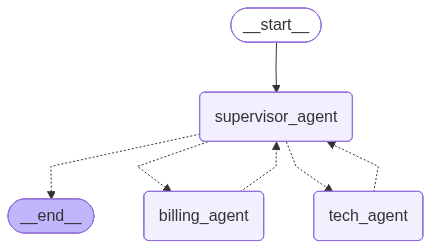

In [9]:
# ---------------------------------------------------
# 그래프 구조 시각화
# ---------------------------------------------------
# 그래프 흐름: START → supervisor_agent → (billing_agent | tech_agent) → supervisor_agent → ... → END
# supervisor_agent: 문의 유형을 분석하고 적절한 에이전트로 핸드오프해요
# billing_agent / tech_agent: 전문 영역 처리 후 supervisor_agent로 복귀해요
# 조건부 엣지: supervisor의 핸드오프 도구 호출에 따라 다음 에이전트로 분기해요
from IPython.display import Image, display

# 그래프 구조를 다이어그램으로 출력해요
display(Image(handoffs_graph.get_graph().draw_mermaid_png()))

In [10]:
# ---------------------------------------------------
# Handoffs 패턴 실행 테스트
# ---------------------------------------------------
# 청구 문의 → supervisor_agent → billing_agent → supervisor_agent 흐름을 확인해요
# === Handoffs 패턴: 청구 문의 테스트 ===

for chunk in handoffs_graph.stream(
    {"messages": [{"role": "user", "content": "지난달 청구 금액이 잘못된 것 같아요"}]},
    stream_mode="updates",
):
    for node_name, node_output in chunk.items():
        if "messages" in node_output and node_output["messages"]:
            last_msg = node_output["messages"][-1]
            # AI 메시지만 출력 (도구 메시지 제외)
            if hasattr(last_msg, "content") and last_msg.content:
                print(f"\n--- {node_name} ---")
                print(last_msg.content[:200])  # 처음 200자만 출력


--- billing_agent ---
지난달 청구 금액에 대한 문제를 해결하기 위해 도움이 필요하신 구체적인 내용을 말씀해 주시겠어요? 어떤 부분이 잘못되었는지 설명해 주시면 더욱 정확히 도와드릴 수 있습니다.

--- supervisor_agent ---
청구 금액에 대한 문제를 해결하기 위해 청구 에이전트에게 문의를 드렸습니다. 그쪽에서 도움을 드릴 수 있을 것입니다.


## 3. Router 패턴 - 병렬 분기 처리

### 개념

**Router 패턴**은 입력을 분류(classify)하여 여러 에이전트에게 **병렬로 dispatch**하는 방식이에요. `Send` API의 자세한 문법은 Part 02에서 이미 배웠고, 여기서는 멀티 에이전트 패턴 관점에서만 짧게 복습합니다.

```mermaid
flowchart LR
    I(["입력"])
    R["라우터<br>Router"]
    A1["에이전트 A<br>(경로 1)"]
    A2["에이전트 B<br>(경로 2)"]
    A3["에이전트 C<br>(경로 3)"]
    O(["결과 집계"])

    I --> R
    R -- "Send(A, ...)" --> A1
    R -- "Send(B, ...)" --> A2
    R -- "Send(C, ...)" --> A3
    A1 --> O
    A2 --> O
    A3 --> O

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404

    class I input
    class R,A1,A2,A3 process
    class O output
```

**Router 패턴의 강점:**
- 여러 에이전트가 **동시에(병렬로)** 작업 처리
- 라우팅 로직이 비교적 명확해서 비용과 지연시간을 예측하기 쉬움
- 같은 질문을 여러 데이터 소스나 전문 역할에 나누어 보낼 때 효과적

> 🔁 **복습 연결**: `Send`는 `02_LangGraph_Basics/04-StateGraph-Basics.ipynb`의 동적 병렬 처리에서 배운 기능입니다. 이 장에서는 `Send` 자체보다 “어떤 멀티 에이전트 문제에 Router가 맞는가?”에 집중하세요.


In [11]:
# ---------------------------------------------------
# Router 패턴: Send API를 이용한 병렬 분기
# ---------------------------------------------------
# 입력 텍스트를 여러 언어로 동시에 번역하는 예제예요
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send


# 전체 그래프의 상태 정의
class TranslationState(TypedDict):
    text: str                   # 번역할 원본 텍스트
    languages: list[str]        # 번역 대상 언어 목록
    translations: list[str]     # 번역 결과 누적 리스트


# 개별 번역 작업의 상태 정의
class SingleTranslation(TypedDict):
    text: str       # 번역할 원본 텍스트
    language: str   # 번역 대상 언어


def route_to_translators(state: TranslationState) -> list[Send]:
    """각 언어에 대한 번역 작업을 병렬로 분기해요."""
    # Send: 특정 노드에 특정 상태를 전달해 병렬 실행해요
    return [
        Send("translate", {"text": state["text"], "language": lang})
        for lang in state["languages"]  # 언어마다 하나의 Send 생성
    ]


def translate(state: SingleTranslation) -> dict:
    """단일 언어로 번역해요 (실제로는 LLM 호출하지만 여기서는 시뮬레이션)."""
    # 시뮬레이션: 실제 배포 시 LLM 호출로 대체해요
    translations_map = {
        "영어": f"[EN] Hello, world! (from: {state['text']})",
        "일본어": f"[JA] こんにちは、世界！(from: {state['text']})",
        "스페인어": f"[ES] ¡Hola, mundo! (from: {state['text']})",
    }
    result = translations_map.get(state["language"], f"[{state['language']}] {state['text']}")
    # 결과를 리스트에 추가해요 (여러 노드가 동시에 추가하므로 리스트 형태)
    return {"translations": [result]}


# Router 패턴 그래프 구성
from operator import add as list_add
from typing import Annotated


class RouterState(TypedDict):
    text: str
    languages: list[str]
    # Annotated[list, add]로 병렬 실행 결과를 자동으로 합쳐요
    translations: Annotated[list[str], list_add]


router_graph = (
    StateGraph(RouterState)
    .add_node("translate", translate)
    .add_conditional_edges(START, route_to_translators, ["translate"])  # 병렬 분기
    .add_edge("translate", END)
    .compile()
)

# Router 패턴 그래프 생성 완료

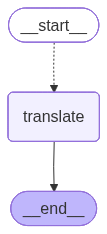

In [12]:
# 그래프 흐름: START → translate (병렬 분기) → END
# route_to_translators: 언어 목록에 따라 Send API로 translate 노드를 병렬 실행해요
# translate: 각 언어별로 독립적으로 번역을 수행해요
# Annotated[list, add]: 병렬 결과를 자동으로 합쳐요
from IPython.display import Image, display
display(Image(router_graph.get_graph().draw_mermaid_png()))

In [13]:
# ---------------------------------------------------
# Router 패턴 실행: 3개 언어로 동시 번역
# ---------------------------------------------------
# 하나의 텍스트를 영어/일본어/스페인어로 동시에 번역해요
result = router_graph.invoke({
    "text": "안녕하세요",
    "languages": ["영어", "일본어", "스페인어"],
    "translations": [],
})

# === Router 패턴: 병렬 번역 결과 ===
print(f"원본 텍스트: {result['text']}")
print(f"번역 언어: {result['languages']}")
# 번역 결과:
for t in result["translations"]:
    print(f"  {t}")

원본 텍스트: 안녕하세요
번역 언어: ['영어', '일본어', '스페인어']
  [EN] Hello, world! (from: 안녕하세요)
  [JA] こんにちは、世界！(from: 안녕하세요)
  [ES] ¡Hola, mundo! (from: 안녕하세요)


## 4. Skills 패턴 - 온디맨드 능력 로딩

### 개념

**Skills 패턴**은 단일 에이전트가 필요에 따라 **능력(skill)**을 동적으로 로드하는 방식이에요. 에이전트를 여러 개 만드는 대신, 하나의 에이전트가 상황에 맞는 능력을 꺼내 써요.

```mermaid
flowchart LR
    U(["사용자"])
    A["단일 에이전트"]
    SM["SkillMiddleware"]
    S1["SQL 스킬"]
    S2["코드 리뷰 스킬"]
    S3["데이터 분석 스킬"]

    U -- "SQL 질문" --> A
    A -- "load_skill('sql')" --> SM
    SM -- "SQL 지식 로드" --> S1
    S1 -- "스킬 주입" --> A
    A -- "응답" --> U

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef storage fill:#e2d5f1,stroke:#6f42c1,color:#3d1f6e

    class U input
    class A,SM process
    class S1,S2,S3 storage
```

**Skills 패턴의 특징:**
- 에이전트가 **1개**뿐이므로 관리가 단순해요
- 스킬은 TypedDict로 정의하고 필요할 때 로드해요
- `load_skill` 도구와 `SkillMiddleware`를 활용해요

> 🎯 **강의 포인트**: Skills 패턴은 스마트폰 앱처럼 기본 에이전트에 앱을 설치하는 개념이에요. 필요할 때만 앱을 실행하고, 나머지는 배경에서 대기해요. 에이전트 수를 줄이면서 유연성은 높일 수 있어요.

> ⚠️ **자주 하는 실수**: 스킬에 너무 많은 내용을 넣으면 컨텍스트가 오히려 늘어나요. 각 스킬은 **하나의 전문 분야**에 집중해야 해요.

In [14]:
# ---------------------------------------------------
# Skills 패턴: TypedDict로 스킬 정의
# ---------------------------------------------------
# Skills는 TypedDict로 구조화된 지식 블록이에요
from typing import TypedDict


class Skill(TypedDict):
    """스킬 구조: 이름, 설명, 시스템 프롬프트, 도구 정보를 포함해요."""
    name: str           # 스킬 식별 이름
    description: str    # 스킬 용도 설명
    system_prompt: str  # 이 스킬을 사용할 때 추가할 시스템 프롬프트
    tools: list[str]    # 이 스킬에서 사용 가능한 도구 목록


# 스킬 레지스트리: 사용 가능한 모든 스킬을 등록해요
SKILL_REGISTRY: dict[str, Skill] = {
    "sql": {
        "name": "sql",
        "description": "SQL 쿼리 작성 및 데이터베이스 작업을 도와줘요",
        "system_prompt": (
            "당신은 SQL 전문가예요. "
            "SELECT, JOIN, GROUP BY, 서브쿼리를 능숙하게 사용해요. "
            "쿼리를 작성할 때 주석을 포함해요."
        ),
        "tools": ["execute_query", "show_tables"],
    },
    "code_review": {
        "name": "code_review",
        "description": "코드 품질 검토 및 개선 제안을 해줘요",
        "system_prompt": (
            "당신은 시니어 소프트웨어 엔지니어예요. "
            "코드를 검토할 때 가독성, 성능, 보안을 모두 체크해요. "
            "구체적인 개선 방안을 제시해요."
        ),
        "tools": ["analyze_code", "suggest_refactoring"],
    },
    "data_analysis": {
        "name": "data_analysis",
        "description": "데이터 통계 분석 및 시각화를 도와줘요",
        "system_prompt": (
            "당신은 데이터 분석 전문가예요. "
            "기술 통계, 상관분석, 시각화 방법을 제안해요. "
            "인사이트를 명확하게 전달해요."
        ),
        "tools": ["calculate_stats", "plot_chart"],
    },
}

print(f"스킬 레지스트리 로드 완료: {list(SKILL_REGISTRY.keys())} ({len(SKILL_REGISTRY)}개 스킬)")

스킬 레지스트리 로드 완료: ['sql', 'code_review', 'data_analysis'] (3개 스킬)


In [15]:
# ---------------------------------------------------
# load_skill 도구: 필요한 스킬을 동적으로 로드해요
# ---------------------------------------------------
from langchain.tools import tool


@tool
def load_skill(skill_name: str) -> str:
    """스킬 이름을 받아서 해당 스킬 정보를 에이전트에게 제공해요.

    Args:
        skill_name: 로드할 스킬 이름 (sql, code_review, data_analysis 중 하나)
    """
    if skill_name not in SKILL_REGISTRY:
        available = ", ".join(SKILL_REGISTRY.keys())
        return f"스킬을 찾을 수 없어요. 사용 가능: {available}"

    skill = SKILL_REGISTRY[skill_name]
    # 스킬 정보를 텍스트로 반환해요 (에이전트의 컨텍스트에 주입됨)
    return (
        f"[{skill['name']} 스킬 로드됨]\n"
        f"설명: {skill['description']}\n"
        f"지침: {skill['system_prompt']}\n"
        f"사용 가능한 도구: {', '.join(skill['tools'])}"
    )


# Skills 패턴 에이전트: load_skill 도구 하나로 모든 스킬에 접근
skills_agent = create_agent(
    model=model,
    tools=[load_skill],  # load_skill 도구만 있으면 돼요
    system_prompt=(
        "당신은 다재다능한 어시스턴트예요. "
        "전문 지식이 필요한 질문을 받으면 load_skill 도구로 해당 스킬을 먼저 로드하세요. "
        "사용 가능한 스킬: sql, code_review, data_analysis\n"
        "스킬 로드 후 해당 전문가처럼 답변해요. 한국어로 답변해요."
    ),
    name="skills_agent",
)

# Skills 패턴 에이전트 생성 완료

In [16]:
# ---------------------------------------------------
# Skills 패턴 테스트: SQL 스킬 온디맨드 로드
# ---------------------------------------------------
# 에이전트가 SQL 질문을 감지하고 스스로 sql 스킬을 로드하는지 확인해요
# === Skills 패턴: SQL 스킬 로드 테스트 ===

for chunk in skills_agent.stream(
    {"messages": [{"role": "user", "content": "고객 테이블에서 최근 30일간 구매한 고객 목록을 조회하는 SQL을 작성해줘"}]},
    stream_mode="updates",
):
    for node_name, output in chunk.items():
        if "messages" in output and output["messages"]:
            last = output["messages"][-1]
            if hasattr(last, "content") and last.content and node_name == "model":
                print(f"\n--- {node_name} ---")
                content = last.content
                # 문자열인 경우만 출력 (리스트 등 다른 타입 무시)
                if isinstance(content, str):
                    print(content[:400])


--- model ---
고객 테이블에서 최근 30일간 구매한 고객 목록을 조회하는 SQL 쿼리는 다음과 같이 작성할 수 있습니다. 여기서는 `purchase_date` 컬럼이 구매한 날짜를 나타내고, `customer_id` 컬럼이 고객을 식별하는 기본 키라고 가정합니다.

```sql
SELECT DISTINCT customer_id
FROM customers
WHERE purchase_date >= NOW() - INTERVAL '30 days';
```

### 쿼리 설명:
- `SELECT DISTINCT customer_id` : 중복되지 않는 고객 ID를 선택합니다.
- `FROM customers` : 고객 정보가 있는 테이블 이름입니다.
- `WHERE purchase_date >= NOW() - INTERVAL '


## 5. Custom Workflow 패턴 - 패턴 조합

### 개념

**Custom Workflow 패턴**은 위에서 배운 4가지 패턴을 **자유롭게 조합**하여 맞춤형 멀티에이전트 시스템을 만드는 방식이에요.

```mermaid
flowchart TB
    U(["사용자 요청"])
    R["Router<br>(분류)"]
    S1["Subagent 흐름<br>(Research + Math)"]
    S2["Handoffs 흐름<br>(전문가 인계)"]
    SK["Skills 흐름<br>(온디맨드)"]    
    AGG["결과 집계"]
    O(["최종 응답"])

    U --> R
    R -- "분석 요청" --> S1
    R -- "지원 요청" --> S2
    R -- "전문 지식" --> SK
    S1 --> AGG
    S2 --> AGG
    SK --> AGG
    AGG --> O

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404

    class U input
    class R,S1,S2,SK,AGG process
    class O output
```

**실제 사용 사례:**
- 고객 지원 시스템: Router(문의 분류) + Handoffs(전문팀 인계) + Skills(제품 지식 로드)
- 리서치 에이전트: Subagents(정보 수집) + Router(병렬 검색) + Custom(최종 합성)

> 🔑 **핵심 개념**: Custom Workflow는 '없는 것을 만드는' 것이 아니라, 이미 배운 패턴들을 **적재적소에 조합**하는 것이에요. 각 패턴의 강점을 이해하면 자연스럽게 최적의 조합이 떠올라요.

> 💡 **실무 팁**: Custom Workflow를 설계할 때는 먼저 **플로우차트**를 그려보세요. 어떤 패턴을 어디에 쓸지 시각화하면 구현이 훨씬 쉬워져요.

In [17]:
# ---------------------------------------------------
# Custom Workflow: 패턴 조합 그래프 구성
# ---------------------------------------------------
# classify → 조건부 분기 → 3가지 처리 흐름
from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict


class WorkflowState(TypedDict):
    query: str      # 사용자 질문
    category: str   # 분류 결과 (math/knowledge/general)
    result: str     # 처리 결과


def classify(state: WorkflowState) -> WorkflowState:
    """질문을 키워드 기반으로 분류해요"""
    query = state["query"].lower()
    if any(kw in query for kw in ["계산", "더하기", "빼기", "곱하기", "나누기", "+", "-", "*", "/"]):
        return {"category": "math"}
    elif any(kw in query for kw in ["sql", "쿼리", "데이터베이스", "테이블", "스킬"]):
        return {"category": "knowledge"}
    else:
        return {"category": "general"}


def math_flow(state: WorkflowState) -> WorkflowState:
    """수학 질문을 처리하는 서브 플로우"""
    response = model.invoke(f"수학 질문에 답해주세요: {state['query']}")
    return {"result": f"[Math] {response.content}"}


def knowledge_flow(state: WorkflowState) -> WorkflowState:
    """전문 지식 질문을 처리하는 서브 플로우"""
    response = model.invoke(f"전문 지식 질문에 답해주세요: {state['query']}")
    return {"result": f"[Knowledge] {response.content}"}


def general_flow(state: WorkflowState) -> WorkflowState:
    """일반 질문을 처리하는 서브 플로우"""
    response = model.invoke(f"일반 질문에 답해주세요: {state['query']}")
    return {"result": f"[General] {response.content}"}


def route_by_category(state: WorkflowState) -> str:
    """분류 결과에 따라 처리 흐름을 선택해요"""
    category = state["category"]
    if category == "math":
        return "math_flow"
    elif category == "knowledge":
        return "knowledge_flow"
    return "general_flow"


# 그래프 구성
builder_custom = StateGraph(WorkflowState)

builder_custom.add_node("classify", classify)
builder_custom.add_node("math_flow", math_flow)
builder_custom.add_node("knowledge_flow", knowledge_flow)
builder_custom.add_node("general_flow", general_flow)

builder_custom.add_edge(START, "classify")
builder_custom.add_conditional_edges("classify", route_by_category)
builder_custom.add_edge("math_flow", END)
builder_custom.add_edge("knowledge_flow", END)
builder_custom.add_edge("general_flow", END)

custom_workflow = builder_custom.compile()

# Custom Workflow 그래프 생성 완료!
# - classify: 키워드 기반 분류
# - math_flow / knowledge_flow / general_flow: 3가지 처리 경로


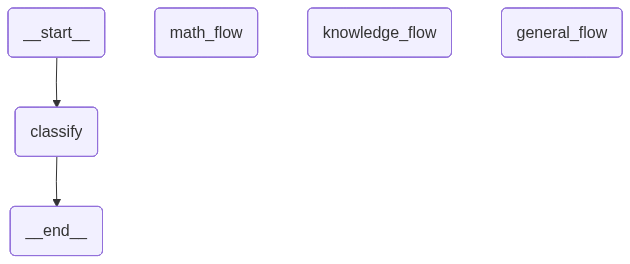

In [18]:
# ---------------------------------------------------
# Custom Workflow 시각화
# ---------------------------------------------------
# 그래프 흐름: START → classify → (math_flow | knowledge_flow | general_flow) → END
# classify: 질문을 키워드 기반으로 math/knowledge/general로 분류해요
# 조건부 엣지: 분류 결과에 따라 3개의 처리 흐름 중 하나로 분기해요
from IPython.display import Image, display

# 그래프 구조를 시각화해요
display(Image(custom_workflow.get_graph().draw_mermaid_png()))

In [19]:
# ---------------------------------------------------
# Custom Workflow 테스트: 3가지 유형의 질문
# ---------------------------------------------------
# 각 질문이 올바른 처리 흐름으로 라우팅되는지 확인해요
test_queries = [
    "15 더하기 27을 계산해줘",           # math_flow로 라우팅
    "SQL로 집계 쿼리를 작성해줘",          # knowledge_flow로 라우팅
    "오늘 날씨가 어때요?",               # general_flow로 라우팅
]

# === Custom Workflow: 라우팅 테스트 ===
for query in test_queries:
    result = custom_workflow.invoke({"query": query, "category": "", "result": ""})
    print(f"\n질문: {query}")
    print(f"결과: {result['result']}")


질문: 15 더하기 27을 계산해줘
결과: [Math] 15 더하기 27은 42입니다.

질문: SQL로 집계 쿼리를 작성해줘
결과: [Knowledge] 물론입니다! SQL에서 집계 쿼리는 특정 열에 대한 집계를 수행하여 결과를 반환하는 쿼리를 의미합니다. 여기서는 기본적인 집계 함수인 `SUM()`, `AVG()`, `COUNT()`, `MAX()`, `MIN()` 등을 활용한 예제 쿼리를 보여드리겠습니다.

예를 들어, `sales`라는 테이블이 있고, 이 테이블에는 `id`, `product`, `amount`, `sale_date`와 같은 열이 있다고 가정해 보겠습니다.

1. **총 판매 금액 조회**:
```sql
SELECT SUM(amount) AS total_sales
FROM sales;
```

2. **판매 제품 수 카운트**:
```sql
SELECT COUNT(DISTINCT product) AS unique_products_sold
FROM sales;
```

3. **각 제품별 평균 판매 금액 조회**:
```sql
SELECT product, AVG(amount) AS average_sales
FROM sales
GROUP BY product;
```

4. **판매 금액의 최대값과 최소값 조회**:
```sql
SELECT MAX(amount) AS max_sale, MIN(amount) AS min_sale
FROM sales;
```

5. **날짜별 총 판매 금액 조회**:
```sql
SELECT sale_date, SUM(amount) AS total_sales_per_day
FROM sales
GROUP BY sale_date
ORDER BY sale_date;
```

위의 쿼리는 각각 다른 집계 작업을 수행하는 예시입니다. 필요한 집계 작업에 따라 적절한 쿼리를 조합하여 사용할 수 있습니다. 추가적으로 궁금한 사항이 있으시면 말씀해 주세요!

질문: 오늘 날씨가 어때요?
결과: [General] 죄송하지만, 

### 패턴 선택 의사결정 트리

어떤 패턴을 선택해야 할지 고민될 때 이 의사결정 트리를 따라가 보세요.

```mermaid
flowchart TD
    Q1{"에이전트 여러 개가<br>필요한가?"}
    Q2{"병렬 처리가<br>필요한가?"}
    Q3{"사용자와 직접<br>대화해야 하나?"}
    Q4{"다단계<br>추론이 필요한가?"}

    A1["Skills 패턴<br>단일 에이전트 + 능력 로딩"]
    A2["Router 패턴<br>Send API 병렬 분배"]
    A3["Handoffs 패턴<br>에이전트 간 제어권 인계"]
    A4["Subagents 패턴<br>중앙 집중 오케스트레이션"]
    A5["Custom Workflow<br>패턴 조합"]

    Q1 -- No --> A1
    Q1 -- Yes --> Q2
    Q2 -- Yes --> A2
    Q2 -- No --> Q3
    Q3 -- Yes --> A3
    Q3 -- No --> Q4
    Q4 -- Yes --> A4
    Q4 -- No --> A5

    classDef question fill:#fff3cd,stroke:#ffc107,color:#856404
    classDef answer fill:#d4edda,stroke:#28a745,color:#155724
    class Q1,Q2,Q3,Q4 question
    class A1,A2,A3,A4,A5 answer
```

> 💡 **실무 팁**: 처음에는 가장 단순한 패턴(Skills)으로 시작하세요. 요구사항이 복잡해지면 점진적으로 더 강력한 패턴으로 전환하는 것이 안전해요.

## 6. 패턴 비교 및 선택 가이드

### Capability Matrix (능력 매트릭스)

각 패턴이 어떤 특성을 가지는지 비교해볼게요:

| 특성 | Subagents | Handoffs | Router | Skills | Custom |
|------|:---------:|:--------:|:------:|:------:|:------:|
| 분산 개발 용이성 | ★★★ | ★★★ | ★★ | ★★ | ★★★ |
| 병렬화 지원 | ★ | ★★ | ★★★ | ★ | ★★★ |
| Multi-hop (다단계 추론) | ★★★ | ★★★ | ★ | ★★ | ★★★ |
| 사용자 상호작용 | ★ | ★★★ | ★★ | ★★ | ★★★ |
| 구현 복잡도 | 중간 | 높음 | 낮음 | 낮음 | 높음 |
| 토큰 비용 | 높음 | 중간 | 낮음 | 낮음 | 가변 |

### Optimization Quick Reference

| 시나리오 | 권장 패턴 | 이유 |
|---------|----------|------|
| 독립적인 병렬 작업 | Router | Send API로 최소 모델 호출 |
| 순차적 전문가 인계 | Handoffs | 에이전트가 직접 사용자와 대화 |
| 중앙 집중식 오케스트레이션 | Subagents | 슈퍼바이저가 전체 컨텍스트 유지 |
| 단일 에이전트 능력 확장 | Skills | 에이전트 수 최소화 |
| 복합 비즈니스 로직 | Custom | 여러 패턴의 장점 조합 |

> 🎯 **강의 포인트**: "어떤 패턴이 '최고'인지는 없어요. 문제 특성에 맞는 패턴을 선택하는 것이 핵심이에요. 처음에는 가장 단순한 패턴부터 시작해보세요."

> ⚠️ **자주 하는 실수**: 모든 문제에 Custom Workflow를 쓰려는 경향이 있어요. 단순한 문제는 단순한 패턴으로도 충분히 해결할 수 있어요. 오버엔지니어링을 피하세요.

In [20]:
# ---------------------------------------------------
# 패턴 선택 도우미 함수
# ---------------------------------------------------
# 문제 특성에 따라 어떤 패턴을 선택할지 가이드해줘요

def recommend_pattern(
    needs_parallel: bool = False,
    needs_user_interaction: bool = False,
    needs_multi_hop: bool = False,
    complexity: str = "low",  # low, medium, high
) -> str:
    """문제 특성에 따라 멀티에이전트 패턴을 추천해요.

    Args:
        needs_parallel: 병렬 처리가 필요한가요?
        needs_user_interaction: 에이전트가 사용자와 직접 대화해야 하나요?
        needs_multi_hop: 여러 단계의 추론이 필요한가요?
        complexity: 전체 시스템 복잡도 (low/medium/high)
    """
    # 간단한 규칙 기반 추천
    if needs_parallel and not needs_user_interaction:
        return "Router 패턴 (Send API로 병렬 처리, 토큰 효율 최고)"
    elif needs_user_interaction and needs_multi_hop:
        return "Handoffs 패턴 (에이전트가 직접 사용자와 대화하며 인계)"
    elif needs_multi_hop and not needs_user_interaction:
        return "Subagents 패턴 (슈퍼바이저가 하위 에이전트들을 순차 호출)"
    elif not needs_multi_hop and complexity == "low":
        return "Skills 패턴 (단일 에이전트, 스킬 동적 로드, 관리 단순)"
    else:
        return "Custom Workflow (여러 패턴 조합, 복잡한 비즈니스 로직)"


# 다양한 시나리오로 테스트
scenarios = [
    {"name": "여러 언어로 동시 번역",          "needs_parallel": True, "needs_user_interaction": False, "needs_multi_hop": False, "complexity": "low"},
    {"name": "고객 지원 인계",               "needs_parallel": False, "needs_user_interaction": True, "needs_multi_hop": True, "complexity": "medium"},
    {"name": "리서치 + 수학 분석",            "needs_parallel": False, "needs_user_interaction": False, "needs_multi_hop": True, "complexity": "medium"},
    {"name": "SQL 전문가 질문",              "needs_parallel": False, "needs_user_interaction": False, "needs_multi_hop": False, "complexity": "low"},
    {"name": "복합 비즈니스 인텔리전스",        "needs_parallel": True, "needs_user_interaction": True, "needs_multi_hop": True, "complexity": "high"},
]

# === 시나리오별 패턴 추천 ===
for s in scenarios:
    pattern = recommend_pattern(
        needs_parallel=s["needs_parallel"],
        needs_user_interaction=s["needs_user_interaction"],
        needs_multi_hop=s["needs_multi_hop"],
        complexity=s["complexity"],
    )
    print(f"\n시나리오: {s['name']}")
    print(f"  → 추천: {pattern}")


시나리오: 여러 언어로 동시 번역
  → 추천: Router 패턴 (Send API로 병렬 처리, 토큰 효율 최고)

시나리오: 고객 지원 인계
  → 추천: Handoffs 패턴 (에이전트가 직접 사용자와 대화하며 인계)

시나리오: 리서치 + 수학 분석
  → 추천: Subagents 패턴 (슈퍼바이저가 하위 에이전트들을 순차 호출)

시나리오: SQL 전문가 질문
  → 추천: Skills 패턴 (단일 에이전트, 스킬 동적 로드, 관리 단순)

시나리오: 복합 비즈니스 인텔리전스
  → 추천: Handoffs 패턴 (에이전트가 직접 사용자와 대화하며 인계)


## 실습: 나만의 패턴 선택해보기

아래 실습 해설 블록을 수정해서 직접 실험해보세요!

In [21]:
# ============================================================
# 실습 해설: 자신의 시나리오에 맞는 패턴을 선택해보세요
# 힌트: 아래 시나리오 중 하나를 선택하거나 직접 만들어보세요
#
# 시나리오 옵션:
#   A. 뉴스 기사를 3개 언어로 동시 번역 → Router
#   B. 법률 상담 봇 (일반질문 → 변호사 인계) → Handoffs
#   C. 여행 플래너 (항공+호텔+관광 조사) → Subagents
#   D. 코딩 튜터 (SQL/Python/JS 전문성 로드) → Skills
#
# 예상 결과: 선택한 시나리오에 맞는 패턴 이유가 출력돼요
# ============================================================

# 내 시나리오 설정 (변경해보세요!)
my_scenario = {
    "name": "여행 플래너 (항공+호텔+관광 동시 조사)",
    "needs_parallel": True,      # 동시에 여러 정보를 조회해야 해요
    "needs_user_interaction": False,  # 사용자가 중간에 개입할 필요 없음
    "needs_multi_hop": False,         # 단일 단계 조회
    "complexity": "medium",
}

# 패턴 추천 실행
my_recommendation = recommend_pattern(
    needs_parallel=my_scenario["needs_parallel"],
    needs_user_interaction=my_scenario["needs_user_interaction"],
    needs_multi_hop=my_scenario["needs_multi_hop"],
    complexity=my_scenario["complexity"],
)

print(f"내 시나리오: {my_scenario['name']}")
print(f"추천 패턴: {my_recommendation}")
# 다른 시나리오로 바꿔서 다시 실행해보세요!

내 시나리오: 여행 플래너 (항공+호텔+관광 동시 조사)
추천 패턴: Router 패턴 (Send API로 병렬 처리, 토큰 효율 최고)


## 핵심 요약

이 노트북에서 다음 내용을 배웠어요:

- **Subagents 패턴**: 슈퍼바이저가 하위 에이전트를 `@tool`로 래핑하여 도구처럼 호출해요. 중앙 집중식 제어, 컨텍스트 유지에 강점
- **Handoffs 패턴**: `Command(goto=agent_name)` + `ToolMessage` 페어링으로 에이전트 간 제어권을 넘겨요. 다중 도메인 대화에 적합
- **Router 패턴**: `Send` API로 여러 에이전트에 병렬 dispatch해요. 모델 호출 최소화, 비용 효율적
- **Skills 패턴**: 단일 에이전트가 `load_skill` 도구로 전문 지식을 동적 로드해요. 에이전트 수 최소화
- **Custom Workflow**: 위 4가지 패턴을 조합하여 복잡한 비즈니스 로직을 구현해요
- **패턴 선택 기준**: 병렬화 필요성, 사용자 상호작용, 다단계 추론, 복잡도를 기준으로 선택해요

## 다음 노트북 예고

다음 `02-Supervisor.ipynb`에서는 **기본 Supervisor 패턴**을 배워요. `langgraph-supervisor` 라이브러리를 사용한 빠른 구현부터, `StateGraph`로 직접 Supervisor를 구현하는 방법까지 단계별로 학습해요.